In [1]:
import numpy as np
import torch

# 1. 원-핫 인코딩 (One-Hot Encoding)

소프트맥스 회귀로 넘어가기 전에, 범주형 데이터를 처리할 때 레이블을 표현하는 방법인 **원-핫 인코딩(One-Hot Encoding)**을 먼저 알아본다.

## 원-핫 인코딩이란?

원-핫 인코딩은 선택지의 개수만큼의 차원을 가지면서, 각 선택지의 인덱스에 해당하는 원소에는 1, 나머지 원소에는 0의 값을 부여하는 표현 방법이다. 예를 들어 강아지, 고양이, 냉장고라는 3개의 선택지가 있다고 하자. 각 선택지에 순차적으로 정수 인덱스를 부여한다 — 강아지는 0번, 고양이는 1번, 냉장고는 2번. 이때 각 선택지의 원-핫 벡터는 다음과 같다.

```text
강아지 = [1, 0, 0]
고양이 = [0, 1, 0]
냉장고 = [0, 0, 1]
```

선택지가 3개였으므로 모두 3차원 벡터가 되었고, 각 벡터는 해당 선택지의 인덱스에만 1, 나머지는 0을 가진다. 이렇게 표현된 벡터를 **원-핫 벡터(one-hot vector)**라 한다.

## 원-핫 벡터의 무작위성

다중 클래스 분류에서 직관적으로 떠올릴 수 있는 레이블링은 클래스 전체에 **정수 인코딩**을 하는 것이다. 예를 들어 {red, green, blue}를 각각 0, 1, 2로 매긴다. 그런데 일반적인 분류 문제에서는 정수 인코딩보다 원-핫 인코딩이 클래스의 성질을 더 잘 표현한다. 그 이유를 살펴본다.

Banana, Tomato, Apple 세 클래스에 정수 인코딩으로 각각 1, 2, 3을 부여하고, 손실 함수로 선형 회귀에서 배운 평균 제곱 오차(MSE)를 사용한다고 하자. ($\hat{y}$ 는 예측값)

$$ \text{Loss function} = \frac{1}{n} \sum_{i}^{n} (y_i - \hat{y}_i)^2 $$

직관적인 비교를 위해 평균을 빼고 제곱 오차만 보면, 실제값이 Tomato인데 예측이 Banana였다면 $(2 - 1)^2 = 1$ 이고, 실제값이 Apple인데 예측이 Banana였다면 $(3 - 1)^2 = 4$ 다.

즉, Banana–Tomato 사이의 오차보다 Banana–Apple 사이의 오차가 더 크다. 이는 기계에게 "Banana가 Apple보다 Tomato에 더 가깝다"는, 의도하지 않은 정보를 주는 것과 같다. 클래스가 더 많아지면 ({Banana:1, Tomato:2, ... Watermelon:10}) 이 왜곡은 더 커진다.

물론 {baby, child, adolescent, adult}나 {1층, 2층, 3층}처럼 클래스에 **순서**의 의미가 있는 경우엔 정수 인코딩이 유용하다. 하지만 일반적인 분류 문제에서는 클래스 간에 순서가 없으므로 오차가 균등한 것이 옳다. 원-핫 인코딩은 이 점에서 모든 클래스 간의 관계를 균등하게 만들어 준다. 세 카테고리에 원-핫 인코딩을 하면 모든 쌍의 제곱 오차가 동일하다.

$$ ((1, 0, 0) - (0, 1, 0))^2 = (1-0)^2 + (0-1)^2 + (0-0)^2 = 2 $$
$$ ((1, 0, 0) - (0, 0, 1))^2 = (1-0)^2 + (0-0)^2 + (0-1)^2 = 2 $$

> 다르게 말하면, 원-핫 벡터들은 모든 쌍에 대해 **유클리드 거리가 전부 동일**하다. 원-핫 벡터는 이처럼 각 클래스 표현이 무작위성(순서 없음)을 가진다는 점을 잘 나타낸다. (뒤에서 이 무작위성은 단어의 유사성을 구할 수 없다는 단점으로 다시 언급된다.)

# 2. 소프트맥스 회귀 (Softmax Regression) 이해하기

앞서 로지스틱 회귀로 2개의 선택지 중 하나를 고르는 **이진 분류(Binary Classification)**를 풀었다. 이번에는 소프트맥스 회귀로 3개 이상의 선택지 중 하나를 고르는 **다중 클래스 분류(Multi-Class Classification)**를 다룬다.

## 다중 클래스 분류 (Multi-Class Classification)

세 개 이상의 답 중 하나를 고르는 문제를 다중 클래스 분류라 한다. 아래는 꽃받침 길이·넓이, 꽃잎 길이·넓이라는 4개의 특성으로부터 setosa, versicolor, virginica라는 3개의 붓꽃 품종 중 하나를 예측하는 전형적인 다중 클래스 분류 문제다.

| SepalLength ($x_1$) | SepalWidth ($x_2$) | PetalLength ($x_3$) | PetalWidth ($x_4$) | Species |
|:---:|:---:|:---:|:---:|:---:|
| 5.1 | 3.5 | 1.4 | 0.2 | setosa |
| 4.9 | 3.0 | 1.4 | 0.2 | setosa |
| 5.8 | 2.6 | 4.0 | 1.2 | versicolor |
| 6.7 | 3.0 | 5.2 | 2.3 | virginica |
| 5.6 | 2.8 | 4.9 | 2.0 | virginica |

> 이 챕터에서 입력은 $X$, 가중치는 $W$, 편향은 $B$, 출력은 $\hat{Y}$ 로 표기하며 각 변수는 벡터 또는 행렬로 가정한다. $\hat{Y}$ 는 예측값이라는 의미이므로 가설식에서 $H(X)$ 대신 쓰이기도 한다.

### 로지스틱 회귀 복습

로지스틱 회귀에서 시그모이드 함수는 예측값을 0과 1 사이의 값으로 만든다. 예를 들어 스팸 메일 분류기의 출력이 0.75라면 스팸일 확률이 75%, 스팸이 아닐 확률이 25%이고, 두 확률의 합은 1이다.

$$ \text{가설} : H(X) = sigmoid(WX + B) $$

### 소프트맥스 회귀

소프트맥스 회귀는 "확률의 총합이 1"이라는 이 아이디어를 다중 클래스 분류에 적용한다. 각 클래스(선택지)마다 소수 확률을 할당하되, 총합이 1이 되게 한다. 그러면 각 선택지가 정답일 확률로 해석할 수 있다. 결국 선택지 개수만큼의 차원을 가지는 벡터를 만들고, 그 벡터의 원소 합이 1이 되도록 변환하는 함수를 통과시키면 되는데, 이 함수가 바로 **소프트맥스(softmax) 함수**다.

$$ \text{가설} : H(X) = softmax(WX + B) $$

## 소프트맥스 함수 (Softmax Function)

소프트맥스 함수는 분류할 클래스의 총 개수를 $k$ 라 할 때, $k$ 차원의 벡터를 입력받아 각 클래스에 대한 확률을 추정한다.

### 소프트맥스 함수의 이해

$k$ 차원 벡터에서 $i$ 번째 원소를 $z_i$, $i$ 번째 클래스가 정답일 확률을 $p_i$ 라 하면 소프트맥스 함수는 $p_i$ 를 다음과 같이 정의한다.

$$ p_i = \frac{e^{z_i}}{\sum_{j=1}^{k} e^{z_j}} \quad \text{for } i = 1, 2, \dots, k $$

이번 붓꽃 문제는 $k = 3$ 이므로, 3차원 벡터 $z = [z_1\; z_2\; z_3]$ 를 입력받으면 다음을 리턴한다.

$$ softmax(z) = \left[ \frac{e^{z_1}}{\sum_{j=1}^{3} e^{z_j}},\; \frac{e^{z_2}}{\sum_{j=1}^{3} e^{z_j}},\; \frac{e^{z_3}}{\sum_{j=1}^{3} e^{z_j}} \right] = [p_1, p_2, p_3] = \hat{y} $$

$p_1, p_2, p_3$ 는 각각 1·2·3번 클래스가 정답일 확률이며, 모두 0과 1 사이의 값으로 합은 1이다. 여기서 i가 1일 때 virginica, 2일 때 setosa, 3일 때 versicolor일 확률이라고 (임의로) 지정하면 식은 다음과 같이 쓸 수 있다.

$$ softmax(z) = [p_1, p_2, p_3] = [p_{virginica}, p_{setosa}, p_{versicolor}] $$

### 그림을 통한 이해

배치 크기가 1이라고 가정하고(샘플을 1개씩 입력) 두 가지 질문을 짚어 본다.

**첫째, 소프트맥스 함수의 입력을 어떻게 만드는가?** 하나의 샘플은 4개의 독립 변수($x_1 \sim x_4$)를 가지므로 모델은 4차원 벡터를 입력으로 받는다. 그런데 소프트맥스 함수의 입력 벡터는 차원이 클래스 개수(3)와 같아야 하므로, 가중치 연산을 통해 4차원을 3차원 벡터 $z$ 로 변환한다. 이때 화살표(가중치)는 총 $4 \times 3 = 12$ 개이며 전부 다른 값을 가지고, 학습 과정에서 오차를 최소화하는 방향으로 갱신된다.

**둘째, 오차를 어떻게 구하는가?** 소프트맥스의 출력은 클래스 개수만큼의 차원을 가지는 확률 벡터다. 이 예측값과 비교할 실제값이 필요한데, 소프트맥스 회귀에서는 실제값을 **원-핫 벡터**로 표현한다. 예를 들어 실제값이 setosa라면 원-핫 벡터는 `[0, 1, 0]` 이고, 예측값이 `[0, 1, 0]` 에 가까워질수록 오차가 0에 가까워진다. 이 두 벡터의 오차 계산에는 **크로스 엔트로피 함수**를 사용한다. 이후 선형 회귀·로지스틱 회귀와 마찬가지로 오차로부터 가중치와 편향을 업데이트한다.

## 붓꽃 품종 분류하기 행렬 연산으로 이해하기

가설식을 행렬 연산으로 표현한다. 전체 샘플 5개, 특성 4개이므로 입력은 $5 \times 4$ 행렬 $X$ 로 정의한다.

$$ X = \begin{pmatrix} 5.1 & 3.5 & 1.4 & 0.2 \\ 4.9 & 3.0 & 1.4 & 0.2 \\ 5.8 & 2.6 & 4.0 & 1.2 \\ 6.7 & 3.0 & 5.2 & 2.3 \\ 5.6 & 2.8 & 4.9 & 2.0 \end{pmatrix} $$

선택지가 3개이므로 예측값 행렬 $\hat{Y}$ 의 열은 3개여야 하고, 행은 $X$ 의 행과 같아야 하므로 $\hat{Y}$ 의 크기는 $5 \times 3$ 이다.

$$ \hat{Y} = \begin{pmatrix} y_{11} & y_{12} & y_{13} \\ y_{21} & y_{22} & y_{23} \\ y_{31} & y_{32} & y_{33} \\ y_{41} & y_{42} & y_{43} \\ y_{51} & y_{52} & y_{53} \end{pmatrix} $$

$\hat{Y}$($5 \times 3$)는 $X$($5 \times 4$)와 가중치 행렬 $W$ 의 곱으로 얻어지므로, $W$ 의 크기는 $4 \times 3$ 이다. 편향 행렬 $B$ 는 $\hat{Y}$ 와 크기가 같아야 하므로 $5 \times 3$ 이다.

$$ W = \begin{pmatrix} w_{11} & w_{12} & w_{13} \\ w_{21} & w_{22} & w_{23} \\ w_{31} & w_{32} & w_{33} \\ w_{41} & w_{42} & w_{43} \end{pmatrix} \qquad B = \begin{pmatrix} b_1 & b_2 & b_3 \\ b_1 & b_2 & b_3 \\ b_1 & b_2 & b_3 \\ b_1 & b_2 & b_3 \\ b_1 & b_2 & b_3 \end{pmatrix} $$

결과적으로 가설식은 다음과 같다.

$$ \hat{Y} = softmax(XW + B) $$

## 비용 함수 (Cost Function)

소프트맥스 회귀는 비용 함수로 **크로스 엔트로피(Cross Entropy) 함수**를 사용한다.

### 크로스 엔트로피 함수

$y$ 를 실제값(원-핫 벡터), $k$ 를 클래스 개수, $y_j$ 를 실제값 원-핫 벡터의 $j$ 번째 인덱스, $p_j$ 를 샘플이 $j$ 번째 클래스일 확률이라 하면, 하나의 샘플에 대한 비용은 다음과 같다.

$$ cost(W) = -\sum_{j=1}^{k} y_j \log(p_j) $$

이 함수가 왜 적합할까? $c$ 를 실제값 원-핫 벡터에서 1을 가진 원소의 인덱스라 하면, $p_c = 1$ 은 정확히 예측한 경우다. 이를 대입하면 $-1 \cdot \log(1) = 0$ 이 되어 비용이 0이 된다. 즉 이 값을 최소화하는 방향으로 학습한다. 이를 $n$ 개 전체 데이터에 대해 평균 내면 최종 비용 함수는 다음과 같다.

$$ cost(W) = -\frac{1}{n} \sum_{i=1}^{n} \sum_{j=1}^{k} y_j^{(i)} \log(p_j^{(i)}) $$

### 이진 분류에서의 크로스 엔트로피 함수

로지스틱 회귀에서 배운 크로스 엔트로피 식과 달라 보이지만 본질적으로 같다. 로지스틱 회귀의 식은 다음과 같았다.

$$ cost(W) = -(y \log H(X) + (1 - y) \log(1 - H(X))) $$

여기서 $y \to y_1$, $1 - y \to y_2$ 로, $H(X) \to p_1$, $1 - H(X) \to p_2$ 로 치환하면 다음을 얻는다.

$$ -(y_1 \log(p_1) + y_2 \log(p_2)) = -\sum_{i=1}^{2} y_i \log p_i $$

소프트맥스 회귀에서는 클래스 개수가 2로 고정되지 않으므로 2를 $k$ 로 일반화하면 $-\sum_{i=1}^{k} y_i \log p_i$ 가 되어 소프트맥스 회귀의 식과 동일하다. 정리하면, 최종 비용 함수에서 $k = 2$ 라고 가정하면 결국 로지스틱 회귀의 비용 함수와 같다.

$$ cost(W) = -\frac{1}{n} \sum_{i=1}^{n} \sum_{j=1}^{k} y_j^{(i)} \log(p_j^{(i)}) = -\frac{1}{n} \sum_{i=1}^{n} \left[ y^{(i)} \log(p^{(i)}) + (1 - y^{(i)}) \log(1 - p^{(i)}) \right] $$

# 3. 소프트맥스 회귀 다양한 방법으로 구현하기

이번에는 소프트맥스 회귀의 비용 함수를 직접 구현하여 크로스 엔트로피 함수를 이해하고, 파이토치로 로우-레벨, 하이-레벨, `nn.Module`, 클래스 등 가능한 다양한 방법으로 소프트맥스 회귀를 구현한다.

## 소프트맥스 회귀의 비용 함수 구현

먼저 실습에 필요한 도구를 임포트한다. (이 챕터의 비용 함수 실습은 아래 임포트가 이미 진행되었다고 가정한다.)

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F

torch.manual_seed(1)

### 로우-레벨로 구현하기

3개의 원소를 가진 벡터 텐서를 정의하고 소프트맥스 함수에 통과시켜 본다.

In [3]:
z = torch.FloatTensor([1, 2, 3])
hypothesis = F.softmax(z, dim=0)
print(hypothesis)

tensor([0.0900, 0.2447, 0.6652])


3개 원소가 모두 0과 1 사이의 값으로 변환되었다. 원소들의 합이 1인지 확인한다.

In [4]:
hypothesis.sum()

tensor(1.)

합이 1이다. 이번에는 비용 함수를 직접 구현하기 위해 임의의 $3 \times 5$ 행렬을 만든다. 그리고 각 샘플(행)에 대해 소프트맥스를 적용해야 하므로 두 번째 차원을 의미하는 `dim=1` 을 써준다.

In [5]:
z = torch.rand(3, 5, requires_grad=True)
hypothesis = F.softmax(z, dim=1)
print(hypothesis)

tensor([[0.2645, 0.1639, 0.1855, 0.2585, 0.1277],
        [0.2430, 0.1624, 0.2322, 0.1930, 0.1694],
        [0.2226, 0.1986, 0.2326, 0.1594, 0.1868]], grad_fn=<SoftmaxBackward0>)


각 행의 원소 합이 1인 텐서로 변환되었다. 소프트맥스의 출력은 곧 예측값이므로, 위 텐서는 3개의 샘플에 대해 5개 클래스 중 어떤 것이 정답인지 예측한 결과다. 이제 각 샘플에 대한 임의의 레이블을 만든다.

In [6]:
y = torch.randint(5, (3,)).long()
print(y)

tensor([0, 2, 1])


이제 각 레이블에 대해 원-핫 인코딩을 수행한다. `torch.zeros_like(hypothesis)` 로 모든 원소가 0인 $3 \times 5$ 텐서를 만든 뒤, `scatter_` 로 정답 위치에 1을 채운다. `y.unsqueeze(1)` 은 $(3,)$ 크기의 y를 $(3 \times 1)$ 로 만들고, `scatter_(1, ..., 1)` 은 `dim=1` 기준으로 그 위치에 1을 넣으라는 의미다. 연산 뒤 `_` 는 In-place(덮어쓰기) 연산을 뜻한다.

In [7]:
# 모든 원소가 0의 값을 가진 3 × 5 텐서 생성
y_one_hot = torch.zeros_like(hypothesis)
y_one_hot.scatter_(1, y.unsqueeze(1), 1)

tensor([[1., 0., 0., 0., 0.],
        [0., 0., 1., 0., 0.],
        [0., 1., 0., 0., 0.]])

In [8]:
print(y.unsqueeze(1))

tensor([[0],
        [2],
        [1]])


In [9]:
print(y_one_hot)

tensor([[1., 0., 0., 0., 0.],
        [0., 0., 1., 0., 0.],
        [0., 1., 0., 0., 0.]])


이제 비용 함수 연산에 필요한 재료가 준비됐다. 소프트맥스 회귀의 비용 함수는 다음과 같으며, 마이너스 부호를 뒤로 빼면 그 아래 식과 동일하다.

$$ cost(W) = -\frac{1}{n} \sum_{i=1}^{n} \sum_{j=1}^{k} y_j^{(i)} \log(p_j^{(i)}) = \frac{1}{n} \sum_{i=1}^{n} \sum_{j=1}^{k} y_j^{(i)} \times (-\log(p_j^{(i)})) $$

여기서 $\sum_{j=1}^{k}$ 는 `sum(dim=1)`, $\frac{1}{n}\sum_{i=1}^{n}$ 은 `mean()` 으로 구현한다.

In [10]:
cost = (y_one_hot * -torch.log(hypothesis)).sum(dim=1).mean()
print(cost)

tensor(1.4689, grad_fn=<MeanBackward0>)


### 하이-레벨로 구현하기

**(1) `F.softmax()` + `torch.log()` = `F.log_softmax()`**

앞서 소프트맥스의 출력에 로그를 씌울 때는 다음처럼 했다.

In [11]:
# Low level
torch.log(F.softmax(z, dim=1))

tensor([[-1.3301, -1.8084, -1.6846, -1.3530, -2.0584],
        [-1.4147, -1.8174, -1.4602, -1.6450, -1.7758],
        [-1.5025, -1.6165, -1.4586, -1.8360, -1.6776]], grad_fn=<LogBackward0>)

파이토치는 두 함수를 결합한 `F.log_softmax()` 를 제공한다. 두 출력 결과는 동일하다.

In [12]:
# High level
F.log_softmax(z, dim=1)

tensor([[-1.3301, -1.8084, -1.6846, -1.3530, -2.0584],
        [-1.4147, -1.8174, -1.4602, -1.6450, -1.7758],
        [-1.5025, -1.6165, -1.4586, -1.8360, -1.6776]],
       grad_fn=<LogSoftmaxBackward0>)

**(2) `F.log_softmax()` + `F.nll_loss()` = `F.cross_entropy()`**

앞서 로우-레벨로 구현한 비용 함수(첫 번째 수식)는 다음과 같았다.

In [13]:
# Low level
# 첫번째 수식
(y_one_hot * -torch.log(F.softmax(z, dim=1))).sum(dim=1).mean()

tensor(1.4689, grad_fn=<MeanBackward0>)

여기서 `torch.log(F.softmax(z, dim=1))` 를 `F.log_softmax()` 로 대체할 수 있다(두 번째 수식).

In [14]:
# 두번째 수식
(y_one_hot * - F.log_softmax(z, dim=1)).sum(dim=1).mean()

tensor(1.4689, grad_fn=<MeanBackward0>)

이를 더 간단히 하면 `F.nll_loss()` 를 쓸 수 있다(세 번째 수식). `nll_loss` 는 **Negative Log Likelihood**의 약자이며, `F.log_softmax()` 이후의 수식을 수행한다. 이때는 원-핫 벡터가 아니라 바로 실제값 y를 인자로 넣는다.

In [15]:
# High level
# 세번째 수식
F.nll_loss(F.log_softmax(z, dim=1), y)

tensor(1.4689, grad_fn=<NllLossBackward0>)

마지막으로 `F.cross_entropy()` 는 `F.log_softmax()` 와 `F.nll_loss()` 를 모두 포함한다(네 번째 수식).

In [16]:
# 네번째 수식
F.cross_entropy(z, y)

tensor(1.4689, grad_fn=<NllLossBackward0>)

> **여기서 잠깐!** `F.cross_entropy` 는 비용 함수에 **소프트맥스 함수까지 포함**하고 있다. 따라서 가설에서 소프트맥스를 또 적용하지 않도록 주의해야 구현 시 혼동하지 않는다.

### nn.CrossEntropyLoss() : 클래스를 이용한 방식

`F.cross_entropy()` 와 `nn.CrossEntropyLoss()` 의 차이는 함수냐 클래스냐다.

> `F.cross_entropy()` 는 **함수**다.
> - 호출할 때마다 `F.cross_entropy(입력, 정답)` 형태로 사용하며, 매번 필요한 설정을 인자로 전달해야 한다.
>
> `nn.CrossEntropyLoss()` 는 **클래스**다.
> - 설정값을 저장하는 틀(template)이며, 객체(instance)를 생성해 사용한다.
> - 객체를 만들 때 설정값을 미리 정해 두고 이후 계속 재사용할 수 있다.

아래는 클래스로 객체를 생성함과 동시에 바로 호출한 것이다.

In [17]:
nn.CrossEntropyLoss()(z, y)

tensor(1.4689, grad_fn=<NllLossBackward0>)

실제로는 다음처럼 객체를 한 번 만들어 두고 재사용하는 경우가 보편적이다.

In [18]:
# 1단계: 클래스로 객체 생성
criterion = nn.CrossEntropyLoss()
# 2단계: 생성된 객체 사용
loss = criterion(z, y)
print(loss)

tensor(1.4689, grad_fn=<NllLossBackward0>)


특별한 설정이 필요한 경우, 예를 들어 손실값의 평균 대신 합계가 필요하다면 객체 생성 시 `reduction='sum'` 한 번만 지정하면 된다. 함수 방식이라면 매번 `reduction='sum'` 을 반복해서 써줘야 한다.

In [19]:
# 평균 대신 합계를 구하는 설정 (클래스: 한 번만 지정)
criterion = nn.CrossEntropyLoss(reduction='sum')
loss_sum = criterion(z, y)
print(loss_sum)

# 함수 방식에서는 매번 설정을 반복해야 함
loss_sum_fn = F.cross_entropy(z, y, reduction='sum')
print(loss_sum_fn)

tensor(4.4068, grad_fn=<NllLossBackward0>)
tensor(4.4068, grad_fn=<NllLossBackward0>)


> **여기서 잠깐!** `nn.CrossEntropyLoss()` 도 `F.cross_entropy()` 와 마찬가지로 비용 함수에 **소프트맥스 함수까지 포함**하고 있음을 기억하자.

## 소프트맥스 회귀 구현하기

### 데이터셋 준비

이제 본격적으로 소프트맥스 회귀를 구현한다. 필요한 도구를 임포트하고 훈련 데이터를 선언한다.

In [20]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

torch.manual_seed(1)

x_train의 각 샘플은 4개의 특성을 가지며 총 8개의 샘플이 있다. y_train은 0, 1, 2의 값을 가지므로 클래스가 3개다.

In [21]:
x_train = [[1, 2, 1, 1],
           [2, 1, 3, 2],
           [3, 1, 3, 4],
           [4, 1, 5, 5],
           [1, 7, 5, 5],
           [1, 2, 5, 6],
           [1, 6, 6, 6],
           [1, 7, 7, 7]]
y_train = [2, 2, 2, 1, 1, 1, 0, 0]
x_train = torch.FloatTensor(x_train)
y_train = torch.LongTensor(y_train)

x_train과 y_train의 크기를 확인한다.

In [22]:
print(x_train.shape)
print(y_train.shape)

torch.Size([8, 4])
torch.Size([8])


x_train은 $8 \times 4$, y_train은 $(8,)$ 이다. 로우-레벨 구현에서는 레이블을 원-핫 인코딩해야 한다. 클래스가 3개이므로 원-핫 인코딩 결과 `y_one_hot` 의 크기는 $8 \times 3$ 이고, 따라서 $W$ 의 크기는 $4 \times 3$ 이어야 한다.

In [23]:
y_one_hot = torch.zeros(8, 3)
y_one_hot.scatter_(1, y_train.unsqueeze(1), 1)
print(y_one_hot.shape)

torch.Size([8, 3])


### 소프트맥스 회귀 구현하기 (로우-레벨)

$W$ 와 $b$ 를 선언하고 옵티마이저로 경사 하강법(SGD)을 학습률 0.1로 사용한다. 1000번의 에포크 동안 학습한다. 가설에는 `F.softmax` 를 직접 사용하고, 비용 함수도 원-핫 인코딩된 실제값과 가설의 로그값을 곱해 직접 계산한다.

In [24]:
# 모델 초기화
W = torch.zeros((4, 3), requires_grad=True)
b = torch.zeros((1, 3), requires_grad=True)
# optimizer 설정
optimizer = optim.SGD([W, b], lr=0.1)

nb_epochs = 1000
for epoch in range(nb_epochs + 1):

    # 가설
    hypothesis = F.softmax(x_train.matmul(W) + b, dim=1)

    # 비용 함수
    cost = (y_one_hot * -torch.log(hypothesis)).sum(dim=1).mean()

    # cost로 H(x) 개선
    optimizer.zero_grad()
    cost.backward()
    optimizer.step()

    # 100번마다 로그 출력
    if epoch % 100 == 0:
        print('Epoch {:4d}/{} Cost: {:.6f}'.format(
            epoch, nb_epochs, cost.item()
        ))

Epoch    0/1000 Cost: 1.098612
Epoch  100/1000 Cost: 0.704199
Epoch  200/1000 Cost: 0.622999
Epoch  300/1000 Cost: 0.565717
Epoch  400/1000 Cost: 0.515291
Epoch  500/1000 Cost: 0.467661
Epoch  600/1000 Cost: 0.421278
Epoch  700/1000 Cost: 0.375402
Epoch  800/1000 Cost: 0.329766
Epoch  900/1000 Cost: 0.285072
Epoch 1000/1000 Cost: 0.248155


### 소프트맥스 회귀 구현하기 (하이-레벨)

이번에는 `F.cross_entropy()` 로 비용 함수를 구현한다. 주의할 점은 `F.cross_entropy()` 가 그 자체로 소프트맥스를 포함하므로 **가설에서는 소프트맥스를 쓰지 않는다**는 것이다. 동일한 x_train, y_train을 사용하며 `F.cross_entropy()` 를 쓰는 것 외에는 위 코드와 같다.

In [25]:
# 모델 초기화
W = torch.zeros((4, 3), requires_grad=True)
b = torch.zeros((1, 3), requires_grad=True)
# optimizer 설정
optimizer = optim.SGD([W, b], lr=0.1)

nb_epochs = 1000
for epoch in range(nb_epochs + 1):

    # Cost 계산
    z = x_train.matmul(W) + b
    cost = F.cross_entropy(z, y_train)

    # cost로 H(x) 개선
    optimizer.zero_grad()
    cost.backward()
    optimizer.step()

    # 100번마다 로그 출력
    if epoch % 100 == 0:
        print('Epoch {:4d}/{} Cost: {:.6f}'.format(
            epoch, nb_epochs, cost.item()
        ))

Epoch    0/1000 Cost: 1.098612
Epoch  100/1000 Cost: 0.704199
Epoch  200/1000 Cost: 0.623000
Epoch  300/1000 Cost: 0.565717
Epoch  400/1000 Cost: 0.515291
Epoch  500/1000 Cost: 0.467662
Epoch  600/1000 Cost: 0.421278
Epoch  700/1000 Cost: 0.375402
Epoch  800/1000 Cost: 0.329766
Epoch  900/1000 Cost: 0.285073
Epoch 1000/1000 Cost: 0.248155


### 소프트맥스 회귀 nn.Module로 구현하기

선형 회귀에서 쓰던 `nn.Linear()` 를 사용한다. 단, output_dim이 1이었던 선형 회귀와 달리 여기서는 클래스의 개수인 3이어야 한다. 아래에서 `F.cross_entropy()` 를 사용하므로 소프트맥스는 가설에 따로 정의하지 않는다.

In [26]:
# 모델을 선언 및 초기화. 4개의 특성을 가지고 3개의 클래스로 분류. input_dim=4, output_dim=3.
model = nn.Linear(4, 3)

# optimizer 설정
optimizer = optim.SGD(model.parameters(), lr=0.1)

nb_epochs = 1000
for epoch in range(nb_epochs + 1):

    # H(x) 계산
    prediction = model(x_train)

    # cost 계산
    cost = F.cross_entropy(prediction, y_train)

    # cost로 H(x) 개선
    optimizer.zero_grad()
    cost.backward()
    optimizer.step()

    # 100번마다 로그 출력
    if epoch % 100 == 0:
        print('Epoch {:4d}/{} Cost: {:.6f}'.format(
            epoch, nb_epochs, cost.item()
        ))

Epoch    0/1000 Cost: 1.616785
Epoch  100/1000 Cost: 0.658891
Epoch  200/1000 Cost: 0.573443
Epoch  300/1000 Cost: 0.518151
Epoch  400/1000 Cost: 0.473265
Epoch  500/1000 Cost: 0.433516
Epoch  600/1000 Cost: 0.396563
Epoch  700/1000 Cost: 0.360914
Epoch  800/1000 Cost: 0.325392
Epoch  900/1000 Cost: 0.289178
Epoch 1000/1000 Cost: 0.254148


### 소프트맥스 회귀 클래스로 구현하기

`nn.Module` 을 상속받은 클래스로 구현한다. `__init__` 에서 입력 차원 4, 출력 차원 3인 선형 계층을 정의한다(출력이 3인 이유는 3개 클래스를 예측하기 때문). `forward` 는 순전파 과정을 정의한다. 여기서 반환되는 예측값은 아직 소프트맥스를 거치지 않은 상태이며, 소프트맥스는 `F.cross_entropy()` 안에 포함되어 있다.

In [27]:
class SoftmaxClassifierModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(4, 3)  # Output이 3!

    def forward(self, x):
        return self.linear(x)

In [28]:
model = SoftmaxClassifierModel()

# optimizer 설정
optimizer = optim.SGD(model.parameters(), lr=0.1)

nb_epochs = 1000
for epoch in range(nb_epochs + 1):

    # H(x) 계산
    prediction = model(x_train)

    # cost 계산
    cost = F.cross_entropy(prediction, y_train)

    # cost로 H(x) 개선
    optimizer.zero_grad()
    cost.backward()
    optimizer.step()

    # 100번마다 로그 출력
    if epoch % 100 == 0:
        print('Epoch {:4d}/{} Cost: {:.6f}'.format(
            epoch, nb_epochs, cost.item()
        ))

Epoch    0/1000 Cost: 2.637636
Epoch  100/1000 Cost: 0.647903
Epoch  200/1000 Cost: 0.564643
Epoch  300/1000 Cost: 0.511043
Epoch  400/1000 Cost: 0.467249
Epoch  500/1000 Cost: 0.428280
Epoch  600/1000 Cost: 0.391924
Epoch  700/1000 Cost: 0.356742
Epoch  800/1000 Cost: 0.321577
Epoch  900/1000 Cost: 0.285617
Epoch 1000/1000 Cost: 0.250818


# 4. 소프트맥스 회귀로 MNIST 데이터 분류하기

이제 MNIST 데이터를 이해하고, 파이토치로 소프트맥스 회귀를 구현하여 MNIST를 분류하는 실습을 진행한다.

## MNIST 데이터 이해하기

MNIST는 숫자 0부터 9까지의 손글씨 이미지로 구성된 데이터셋이다. 과거 우체국에서 우편 번호를 인식하기 위해 만들어진 데이터로, 총 **60,000개의 훈련 데이터**와 **10,000개의 테스트 데이터**로 구성되며 레이블은 0~9까지 10개다. 손글씨 숫자 이미지가 들어오면 그 숫자가 무엇인지 맞히는 문제로, 사람에게는 쉽지만 기계에게는 그렇지 않다.

각 이미지는 **28 픽셀 × 28 픽셀**이다. 이 문제를 풀기 위해 $28 \times 28 = 784$ 이므로, 각 이미지를 784개의 원소를 가진 벡터로 펼친다. 즉 하나의 샘플이 784개의 특성을 가지게 되며, 이는 지금까지 다룬 어떤 문제보다 특성이 많다.

784차원 벡터로 만드는 코드를 미리 보면 다음과 같다.

```python
for X, Y in data_loader:
    # 입력 이미지를 [batch_size × 784]의 크기로 reshape
    # 레이블은 원-핫 인코딩
    X = X.view(-1, 28*28)
```

X는 for문에서 호출될 때 (배치 크기 × 1 × 28 × 28)의 크기를 가지지만, `view` 를 통해 (배치 크기 × 784)로 변환된다.

## 토치비전 (torchvision) 소개하기

**torchvision**은 유명한 데이터셋들, 이미 구현된 유명한 모델들, 일반적인 이미지 전처리 도구(transforms)를 포함하는 패키지다. 어떤 데이터셋·모델·전처리를 제공하는지는 파이토치 공식 문서에서 확인할 수 있다. (참고로 자연어 처리를 위해서는 **torchtext** 패키지가 있다.)

## 분류기 구현을 위한 사전 설정

필요한 도구들을 임포트한다.

In [29]:
import torch
import torchvision.datasets as dsets
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import torch.nn as nn
import matplotlib.pyplot as plt
import random

GPU 연산이 가능하면 GPU를, 아니면 CPU를 사용하도록 한다. Colab에서 '런타임 > 런타임 유형 변경 > 하드웨어 가속기 > GPU'를 선택하면 `USE_CUDA` 가 True가 되어 cuda로 학습한다. 이 방식은 앞으로 자주 쓰이므로 기억해 둔다.

In [30]:
USE_CUDA = torch.cuda.is_available()  # GPU를 사용가능하면 True, 아니라면 False를 리턴
device = torch.device("cuda" if USE_CUDA else "cpu")  # GPU 사용 가능하면 사용하고 아니면 CPU 사용
print("다음 기기로 학습합니다:", device)

다음 기기로 학습합니다: cpu


랜덤 시드를 고정한다.

In [31]:
# for reproducibility
random.seed(777)
torch.manual_seed(777)
if device == 'cuda':
    torch.cuda.manual_seed_all(777)

하이퍼파라미터를 변수로 둔다.

In [32]:
# hyperparameters
training_epochs = 15
batch_size = 100

## MNIST 분류기 구현하기

`torchvision.datasets.MNIST` 로 MNIST 데이터셋을 불러온다. 첫 번째 인자 `root` 는 다운로드 경로, 두 번째 인자 `train` 은 True면 훈련 데이터·False면 테스트 데이터를 리턴, 세 번째 인자 `transform` 은 데이터를 파이토치 텐서로 변환, 네 번째 인자 `download` 는 해당 경로에 데이터가 없으면 다운로드하겠다는 의미다.

In [33]:
# MNIST dataset
mnist_train = dsets.MNIST(root='MNIST_data/',
                          train=True,
                          transform=transforms.ToTensor(),
                          download=True)

mnist_test = dsets.MNIST(root='MNIST_data/',
                         train=False,
                         transform=transforms.ToTensor(),
                         download=True)

100%|██████████| 9.91M/9.91M [00:00<00:00, 55.4MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.75MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.5MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 4.20MB/s]


앞서 미니 배치와 데이터로드 챕터에서 배운 `DataLoader` 를 사용한다. 인자는 `dataset`(로드 대상), `batch_size`(배치 크기), `shuffle`(매 에포크마다 미니 배치 셔플 여부), `drop_last`(마지막 배치를 버릴지 여부)다.

> **drop_last를 하는 이유** : 1,000개의 데이터에 배치 크기가 128이면 7개 배치가 나오고 104개가 남는다. 이 마지막 104개 배치는 다른 배치보다 개수가 적어, 경사 하강법에서 상대적으로 과대 평가될 수 있다. `drop_last=True` 로 이 마지막 배치를 버려 이런 현상을 막는다.

In [34]:
# dataset loader
data_loader = DataLoader(dataset=mnist_train,
                         batch_size=batch_size,  # 배치 크기는 100
                         shuffle=True,
                         drop_last=True)

이제 모델을 설계한다. input_dim은 784, output_dim은 10이다.

`to()` 함수는 연산을 어디서 수행할지를 정한다. 모델의 매개변수를 지정한 장치의 메모리로 보내며, GPU를 쓰려면 `to('cuda')` 가 필요하다(CPU면 생략 가능). `bias` 는 편향 b 사용 여부로 기본값이 True이지만 명시적으로 적어 주었다.

In [35]:
# MNIST data image of shape 28 * 28 = 784
linear = nn.Linear(784, 10, bias=True).to(device)

비용 함수와 옵티마이저를 정의한다. 앞서 소프트맥스 회귀를 배울 때는 `F.cross_entropy()` 를 썼지만, 여기서는 클래스 방식인 `nn.CrossEntropyLoss()` 를 사용한다. 둘 다 소프트맥스 함수를 포함한다.

In [36]:
# 비용 함수와 옵티마이저 정의
criterion = nn.CrossEntropyLoss().to(device)  # 내부적으로 소프트맥스 함수를 포함하고 있음.
optimizer = torch.optim.SGD(linear.parameters(), lr=0.1)

이제 학습을 진행한다. 총 15 에포크 동안, 각 배치마다 입력 X를 `(100, 784)` 로 변환하고(배치 크기 100, 28×28 픽셀을 일렬로 펼침) 레이블 Y와 함께 장치로 보낸다. 기울기를 초기화한 뒤 가설 `linear(X)` 로 순전파하여 예측값을 구하고, `criterion` 으로 비용을 계산한다. `cost.backward()` 로 역전파하여 기울기를 구하고 `optimizer.step()` 으로 파라미터를 갱신한다. 각 배치의 비용을 누적해 에포크당 평균 비용 `avg_cost` 를 출력한다.

In [37]:
for epoch in range(training_epochs):  # 앞서 training_epochs의 값은 15로 지정함.
    avg_cost = 0
    total_batch = len(data_loader)

    for X, Y in data_loader:
        # 배치 크기가 100이므로 아래의 연산에서 X는 (100, 784)의 텐서가 된다.
        X = X.view(-1, 28 * 28).to(device)
        # 레이블은 원-핫 인코딩이 된 상태가 아니라 0 ~ 9의 정수.
        Y = Y.to(device)

        optimizer.zero_grad()
        hypothesis = linear(X)
        cost = criterion(hypothesis, Y)
        cost.backward()
        optimizer.step()

        avg_cost += cost / total_batch

    print('Epoch:', '%04d' % (epoch + 1), 'cost =', '{:.9f}'.format(avg_cost))

print('Learning finished')

Epoch: 0001 cost = 0.535150588
Epoch: 0002 cost = 0.359577775
Epoch: 0003 cost = 0.331264287
Epoch: 0004 cost = 0.316404670
Epoch: 0005 cost = 0.307107031
Epoch: 0006 cost = 0.300456554
Epoch: 0007 cost = 0.294933408
Epoch: 0008 cost = 0.290956199
Epoch: 0009 cost = 0.287074089
Epoch: 0010 cost = 0.284515619
Epoch: 0011 cost = 0.281914055
Epoch: 0012 cost = 0.279526889
Epoch: 0013 cost = 0.277636588
Epoch: 0014 cost = 0.275874764
Epoch: 0015 cost = 0.274422795
Learning finished


학습된 모델을 테스트 데이터로 평가하고, 임의의 이미지 하나를 뽑아 모델이 어떻게 예측하는지 시각적으로 확인한다.

- **평가 모드** : `with torch.no_grad():` 블록 안에서는 기울기 계산을 하지 않아 메모리와 연산 효율이 높아진다.
- **테스트 데이터 준비** : `mnist_test.test_data` 를 `view(-1, 28*28)` 로 펼치고 `.float()` 로 실수형 변환, `.to(device)` 로 장치에 배치한다. `mnist_test.test_labels` 는 정답 레이블이다.
- **예측 및 정확도** : `torch.argmax(prediction, 1)` 로 각 이미지의 예측 클래스를 구해 실제 레이블과 비교하고, `correct_prediction.float().mean()` 으로 전체 정확도를 계산한다.
- **임의 샘플 예측** : `random.randint` 로 테스트 샘플 하나를 골라 예측 결과와 실제 레이블을 출력한다.
- **이미지 시각화** : `plt.imshow()` 로 이미지를 보여 준다. `cmap='Greys'` 는 회색조, `interpolation='nearest'` 는 확대 시 보간을 최소화해 원본 형태를 유지한다.

Accuracy: 0.8883000016212463
Label:  8
Prediction:  3


/usr/local/lib/python3.12/dist-packages/torchvision/datasets/mnist.py:81: UserWarning: test_data has been renamed data
  warnings.warn("test_data has been renamed data")
/usr/local/lib/python3.12/dist-packages/torchvision/datasets/mnist.py:71: UserWarning: test_labels has been renamed targets
  warnings.warn("test_labels has been renamed targets")


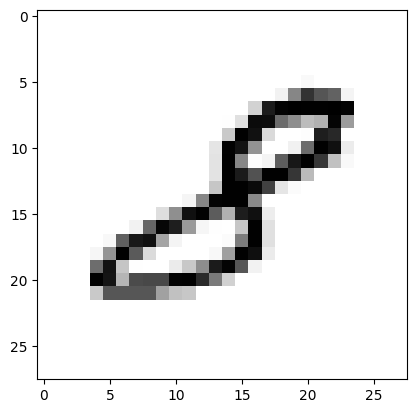

In [38]:
# 테스트 데이터를 사용하여 모델을 테스트한다.
with torch.no_grad():  # torch.no_grad()를 하면 gradient 계산을 수행하지 않는다.
    X_test = mnist_test.test_data.view(-1, 28 * 28).float().to(device)
    Y_test = mnist_test.test_labels.to(device)

    prediction = linear(X_test)
    correct_prediction = torch.argmax(prediction, 1) == Y_test
    accuracy = correct_prediction.float().mean()
    print('Accuracy:', accuracy.item())

    # MNIST 테스트 데이터에서 무작위로 하나를 뽑아서 예측을 해본다
    r = random.randint(0, len(mnist_test) - 1)
    X_single_data = mnist_test.test_data[r:r + 1].view(-1, 28 * 28).float().to(device)
    Y_single_data = mnist_test.test_labels[r:r + 1].to(device)

    print('Label: ', Y_single_data.item())
    single_prediction = linear(X_single_data)
    print('Prediction: ', torch.argmax(single_prediction, 1).item())

    plt.imshow(mnist_test.test_data[r:r + 1].view(28, 28),
               cmap='Greys', interpolation='nearest')
    plt.show()